In [5]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [6]:

def plot_pod_temporal_modes(projectnames, labels, dt, numModes, saveName="POD_temporal_modes.png"):

    if len(projectnames) != len(labels):
        raise ValueError("projectnames and labels must have the same length.")

    ncols = math.ceil(math.sqrt(numModes))
    nrows = math.ceil(numModes / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), squeeze=False)

    for mode in range(1, numModes + 1):

        r = (mode-1) // ncols
        c = (mode-1) % ncols
        ax = axes[r, c]

        for proj, label in zip(projectnames, labels):

            fname = f"{proj}_podTempMode_{mode}.txt"
            data = np.loadtxt(fname)

            t = dt * np.arange(len(data))

            ax.plot(t, data, linewidth=2, label=label)

        ax.set_title(f"POD Mode {mode}")
        ax.set_xlabel("Time")
        ax.set_ylabel("Temporal Coefficient")
        ax.grid(True)
        ax.legend()

    # Hide unused panels
    for k in range(numModes, nrows*ncols):
        r = k // ncols
        c = k % ncols
        axes[r, c].axis("off")

    plt.tight_layout()

    # ---- Save figure
    plt.savefig(saveName, dpi=300, bbox_inches="tight")

    plt.show()

In [7]:
def plot_singular_value_spectra(projectnames, labels,
                                saveNameSpectrum,
                                saveNameEnergy,
                                energy_threshold=None):
    """
    Plot singular value spectrum and cumulative POD energy.

    Parameters
    ----------
    projectnames : list[str]
        Names used to construct filenames "{project}_SV.txt"
    labels : list[str]
        Legend labels corresponding to projectnames
    saveNameSpectrum : str
        Filename for the singular value spectrum figure (png)
    saveNameEnergy : str
        Filename for cumulative energy figure (png)
    energy_threshold : float (0-1), optional
        Horizontal line showing desired cumulative energy level
        (e.g. 0.99 for 99%)
    """

    if len(projectnames) != len(labels):
        raise ValueError("projectnames and labels must have the same length.")

    # =========================================================
    # FIGURE 1: Singular value spectrum
    # =========================================================
    plt.figure(figsize=(6,5))

    for proj, label in zip(projectnames, labels):

        S = np.loadtxt(f"{proj}_SV.txt")

        x = np.arange(1, len(S)+1)

        plt.plot(x, np.log10(S/np.max(S)), linewidth=2, label=label)

    plt.xlabel("Singular Value Index")
    plt.ylabel(r"$\log_{10}(\sigma_i / \sigma_{max})$")
    plt.title("Singular Value Spectrum")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.savefig(saveNameSpectrum, dpi=300, bbox_inches="tight")
    plt.show()


    # =========================================================
    # FIGURE 2: Cumulative POD energy
    # =========================================================
    plt.figure(figsize=(6,5))

    for proj, label in zip(projectnames, labels):

        S = np.loadtxt(f"{proj}_SV.txt")

        energy = S**2
        cumulative_energy = np.cumsum(energy)/np.sum(energy)

        x = np.log10(np.arange(1, len(S)+1))

        plt.plot(x, cumulative_energy, linewidth=2, label=label)

    if energy_threshold is not None:
        plt.axhline(energy_threshold,
                    color='red',
                    linestyle='--',
                    linewidth=2,
                    label=f"{energy_threshold*100:.1f}% energy")

    plt.xlabel(r"$\log_{10}(\text{mode index})$")
    plt.ylabel("Cumulative Energy Fraction")
    plt.title("Cumulative POD Energy")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.savefig(saveNameEnergy, dpi=300, bbox_inches="tight")
    plt.show()

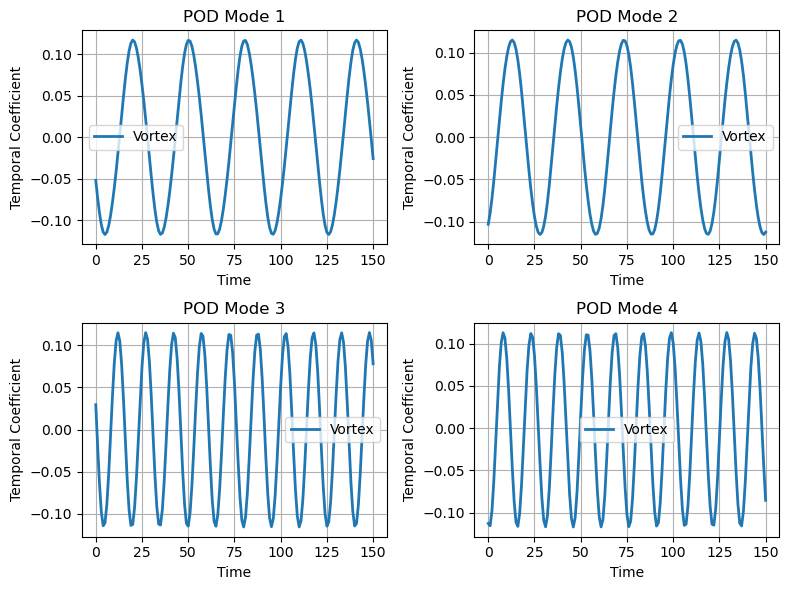

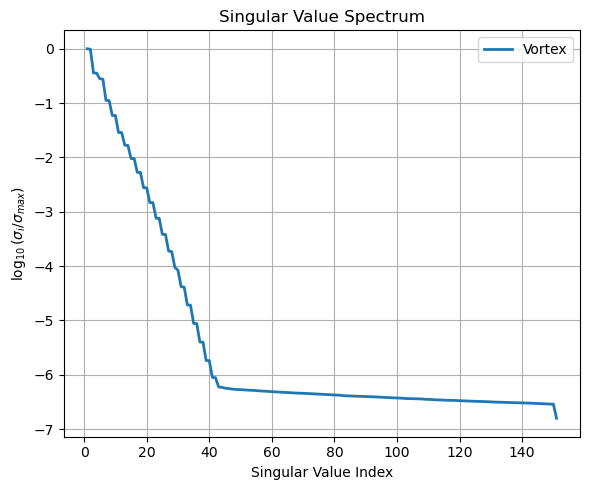

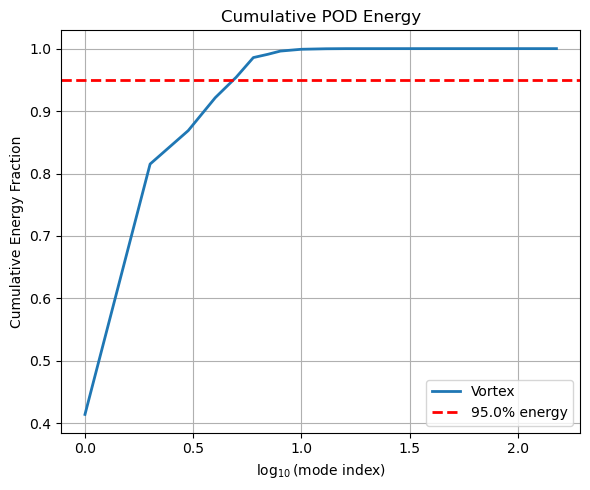

In [8]:
if __name__ == "__main__":
    plot_pod_temporal_modes(["Vortex_Avg"], ["Vortex"], 1, 4, saveName="POD_temporal_modes.png")
    plot_singular_value_spectra(["Vortex_Avg"], ["Vortex"],
                                saveNameSpectrum="SV_Spectrum.png",
                                saveNameEnergy="SVcumu_Energy.png",
                                energy_threshold=0.95)